<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/subseaequipment/subsea_process_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulation of subsea processes with NeqSim

An integrated, steady-state wellhead-to-host example connecting a subsea choke, non-isothermal multiphase flowline, host pressure control, inlet separation, gas recompression, and export cooling. It is intended for senior students and production, flow-assurance, subsea, and process engineers.

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim==3.16.0"])
from importlib.metadata import version
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neqsim.thermo import fluid, TPflash
from neqsim.process import clearProcess, stream, valve, beggs_brill_pipe, separator, compressor, cooler, runProcess
NEQSIM_VERSION = version("neqsim")
print(f"NeqSim {NEQSIM_VERSION}; Python {sys.version.split()[0]}")

NeqSim 3.16.0; Python 3.12.13


## Learning objectives, prerequisites, and boundaries

You should know phase equilibrium, pressure drop, heat transfer, and steady-state balances. After completing the notebook you can: translate a subsea architecture into connected NeqSim objects; explain friction, elevation, and acceleration pressure gradients; inspect pressure, temperature, holdup, velocity, and flow regime; quantify host separation and compression; and perform design sensitivities. The example is a concept-screening model—not a detailed transient slug, hydrate, wax, erosion, integrity, control, or mechanical-design study.

In [2]:
case = {
    "wellhead_pressure_bara": 120.0, "wellhead_temperature_C": 45.0,
    "feed_kg_per_h": 8_000.0, "subsea_choke_pressure_bara": 110.0,
    "flowline_length_m": 20_000.0, "flowline_diameter_m": 0.30,
    "flowline_elevation_m": 200.0, "roughness_m": 50e-6,
    "overall_U_W_per_m2K": 5.0, "seawater_temperature_C": 4.0,
    "host_separator_pressure_bara": 60.0, "export_pressure_bara": 120.0,
    "compressor_isentropic_efficiency": 0.78, "export_temperature_C": 35.0
}
composition_mol_percent = {
    "nitrogen": 1.0, "CO2": 2.0, "methane": 70.0, "ethane": 7.0,
    "propane": 5.0, "i-butane": 1.5, "n-butane": 2.0,
    "i-pentane": 1.0, "n-pentane": 1.0, "n-hexane": 3.0,
    "n-heptane": 3.0, "n-octane": 3.5
}
assert abs(sum(composition_mol_percent.values())-100.0) < 1e-12
pd.Series(case, name="value").to_frame()

,value
wellhead_pressure_bara,120.00000
wellhead_temperature_C,45.00000
feed_kg_per_h,8000.00000
subsea_choke_pressure_bara,110.00000
flowline_length_m,20000.00000
flowline_diameter_m,0.30000
flowline_elevation_m,200.00000
roughness_m,0.00005
overall_U_W_per_m2K,5.00000
seawater_temperature_C,4.00000


## Subsea-to-host architecture

The production chain is: multiphase wellhead stream → subsea choke → 20 km flowline/riser with 200 m net elevation gain → host choke → inlet separator → gas compressor → export cooler. Chokes regulate pressure by approximately isenthalpic expansion. The flowline couples hydraulic pressure loss and heat exchange with cold seawater. Host separation routes light components to gas and heavy components to liquid before gas recompression.

In [3]:
def make_wellstream(flow_kg_h=case["feed_kg_per_h"], pressure_bara=case["wellhead_pressure_bara"], temperature_C=case["wellhead_temperature_C"]):
    system = fluid("pr")
    for component, amount in composition_mol_percent.items(): system.addComponent(component, amount)
    system.setMixingRule("classic")
    system.setMultiPhaseCheck(True)
    system.setPressure(pressure_bara, "bara"); system.setTemperature(temperature_C, "C")
    system.setTotalFlowRate(flow_kg_h, "kg/hr")
    TPflash(system); system.initProperties()
    return system
well_fluid = make_wellstream()
print(f"Wellhead phases: {well_fluid.getNumberOfPhases()} | density: {well_fluid.getDensity('kg/m3'):.2f} kg/m3")

Wellhead phases: 2 | density: 200.80 kg/m3


## Multiphase hydraulics and heat transfer

The total pressure gradient can be written $dP/dL=(dP/dL)_f+(dP/dL)_e+(dP/dL)_a$, representing friction, elevation, and acceleration. In multiphase flow, mixture density depends on liquid holdup rather than only inlet phase fraction. Beggs–Brill predicts flow regime and empirical holdup, then evaluates pressure loss along inclined segments. The thermal calculation balances fluid enthalpy against heat transfer toward ambient seawater, using the specified overall coefficient as a screening input.

In [4]:
def build_integrated_process():
    clearProcess()
    feed = stream("subsea wellhead stream", make_wellstream())
    subsea_choke = valve("subsea production choke", feed)
    subsea_choke.setOutletPressure(case["subsea_choke_pressure_bara"], "bara")
    flowline = beggs_brill_pipe("subsea flowline and riser", subsea_choke.getOutStream(),
        case["flowline_length_m"], case["flowline_diameter_m"], case["flowline_elevation_m"], case["roughness_m"])
    flowline.setHeatTransferCoefficient(case["overall_U_W_per_m2K"])
    flowline.setAmbientTemperature(case["seawater_temperature_C"]+273.15)
    host_choke = valve("host inlet choke", flowline.getOutletStream())
    host_choke.setOutletPressure(case["host_separator_pressure_bara"], "bara")
    inlet_separator = separator("host inlet separator", host_choke.getOutStream())
    gas_compressor = compressor("host gas compressor", inlet_separator.getGasOutStream())
    gas_compressor.setOutletPressure(case["export_pressure_bara"], "bara")
    gas_compressor.setIsentropicEfficiency(case["compressor_isentropic_efficiency"])
    export_cooler = cooler("export gas cooler", gas_compressor.getOutStream())
    export_cooler.setOutTemperature(case["export_temperature_C"], "C")
    runProcess()
    return {"feed":feed, "subsea_choke":subsea_choke, "flowline":flowline, "host_choke":host_choke,
            "separator":inlet_separator, "compressor":gas_compressor, "export_cooler":export_cooler}
base = build_integrated_process()
print("Integrated subsea-to-host process solved.")

Integrated subsea-to-host process solved.


## How NeqSim represents and solves the system

`fluid('pr')` creates a Peng–Robinson thermodynamic system. A `stream` carries that state and flow basis. Each unit obtains its inlet from the preceding outlet, creating a directed process graph. Valve outlets are calculated with a PH flash; pipeline segments repeatedly update pressure, temperature, phases, properties, flow regime, and holdup; the separator performs an equilibrium split; and the compressor applies an EOS-based isentropic calculation plus efficiency. `runProcess()` executes the graph in dependency order.

In [5]:
named_streams = {
    "wellhead": base["feed"], "after subsea choke": base["subsea_choke"].getOutStream(),
    "flowline arrival": base["flowline"].getOutletStream(), "separator feed": base["host_choke"].getOutStream(),
    "separator gas": base["separator"].getGasOutStream(), "separator liquid": base["separator"].getLiquidOutStream(),
    "export gas": base["export_cooler"].getOutStream(),
}
stream_table = pd.DataFrame({name:{
    "mass flow [kg/h]":s.getFlowRate("kg/hr"), "pressure [bara]":s.getPressure("bara"),
    "temperature [degC]":s.getTemperature("C"), "phases [-]":s.getFluid().getNumberOfPhases()
} for name,s in named_streams.items()}).T
stream_table.round(3)

,mass flow [kg/h],pressure [bara],temperature [degC],phases [-]
wellhead,8000.000,120.000,45.000,2.0
after subsea choke,8000.000,110.000,43.213,2.0
flowline arrival,8000.000,101.948,14.582,2.0
separator feed,8000.000,60.000,3.175,2.0
separator gas,3610.279,60.000,3.175,1.0
separator liquid,4389.721,60.000,3.175,1.0
export gas,3610.279,120.000,35.000,1.0


## Inspect the flowline profiles

A single inlet/outlet pressure hides the mechanism. Segment profiles show rapid cooling toward seawater temperature, pressure loss, changing liquid holdup, and superficial mixture velocity. Holdup is the liquid volume fraction occupying the pipe cross-section and can differ strongly from the flowing liquid fraction because gas and liquid velocities differ. Flow-regime labels are correlation results, not direct predictions of transient slug size or frequency.

In [6]:
flowline = base["flowline"]
pressure_profile = np.asarray(list(flowline.getPressureProfile()), dtype=float)
temperature_profile_K = np.asarray(list(flowline.getTemperatureProfile()), dtype=float)
holdup_profile = np.asarray(list(flowline.getLiquidHoldupProfile()), dtype=float)
velocity_profile = np.asarray(list(flowline.getMixtureSuperficialVelocityProfile()), dtype=float)
distance_km = np.linspace(0.0, case["flowline_length_m"]/1000.0, len(pressure_profile))
profile_table = pd.DataFrame({
    "distance [km]":distance_km, "pressure [bara]":pressure_profile,
    "temperature [degC]":temperature_profile_K-273.15, "liquid holdup [-]":holdup_profile,
    "mixture superficial velocity [m/s]":velocity_profile
})
print(f"Predicted outlet flow regime: {flowline.getFlowRegime()}")
profile_table.round(4)

Predicted outlet flow regime: SEGREGATED


,distance [km],pressure [bara],temperature [degC],liquid holdup [-],mixture superficial velocity [m/s]
0,0.0,110.0000,43.2127,0.6423,0.1704
1,4.0,108.5580,18.8186,0.7617,0.1452
2,8.0,106.9135,15.2095,0.7726,0.1434
3,12.0,105.2475,14.6779,0.7637,0.1454
4,16.0,103.5908,14.5965,0.7519,0.1480
5,20.0,101.9481,14.5815,0.7398,0.1508


## Balances and choke thermodynamics

Overall host separation requires $\dot m_{feed}=\dot m_{gas}+\dot m_{liquid}$. Each valve should conserve specific enthalpy to numerical tolerance when heat, shaft work, and kinetic/potential changes are neglected. The pipeline pressure difference must agree with the profile endpoints. These independent checks catch wiring, units, and stale-state errors before design conclusions are drawn.

In [7]:
feed_mass = base["feed"].getFlowRate("kg/hr")
gas_mass = base["separator"].getGasOutStream().getFlowRate("kg/hr")
liquid_mass = base["separator"].getLiquidOutStream().getFlowRate("kg/hr")
mass_residual = (gas_mass+liquid_mass-feed_mass)/feed_mass
h_subsea_in = base["feed"].getFluid().getEnthalpy("J/kg")
h_subsea_out = base["subsea_choke"].getOutStream().getFluid().getEnthalpy("J/kg")
h_host_in = base["flowline"].getOutletStream().getFluid().getEnthalpy("J/kg")
h_host_out = base["host_choke"].getOutStream().getFluid().getEnthalpy("J/kg")
subsea_h_residual = (h_subsea_out-h_subsea_in)/max(abs(h_subsea_in),1.0)
host_h_residual = (h_host_out-h_host_in)/max(abs(h_host_in),1.0)
profile_drop = pressure_profile[0]-pressure_profile[-1]
pd.Series({"overall mass residual [-]":mass_residual, "subsea choke enthalpy residual [-]":subsea_h_residual,
           "host choke enthalpy residual [-]":host_h_residual, "flowline pressure drop [bar]":flowline.getPressureDrop(),
           "profile endpoint drop [bar]":profile_drop}).to_frame("value")

,value
overall mass residual [-],1.718831e-11
subsea choke enthalpy residual [-],3.939633e-13
host choke enthalpy residual [-],7.140376e-11
flowline pressure drop [bar],8.051882e+00
profile endpoint drop [bar],8.051882e+00


## Isolate diameter and friction effects

In an uphill multiphase line, a larger diameter can increase hydrostatic loss by increasing liquid holdup even while friction decreases. To demonstrate the familiar friction trend without mixing mechanisms, this diameter sweep uses a horizontal, adiabatic line at the same inlet state. The result should show lower pressure drop and lower velocity with increasing diameter. The actual riser case must retain elevation and thermal coupling.

In [8]:
def flowline_screen(diameter=0.30, U=5.0, flow_kg_h=8_000.0, elevation=200.0, length=20_000.0):
    inlet = make_wellstream(flow_kg_h, 110.0, 43.2127405)
    clearProcess(); inlet_stream = stream("screen inlet", inlet)
    line = beggs_brill_pipe("screen flowline", inlet_stream, length, diameter, elevation, case["roughness_m"])
    line.setHeatTransferCoefficient(U); line.setAmbientTemperature(case["seawater_temperature_C"]+273.15)
    runProcess()
    return {"pressure drop [bar]":line.getPressureDrop(), "outlet temperature [degC]":line.getOutletStream().getTemperature("C"),
            "outlet holdup [-]":float(list(line.getLiquidHoldupProfile())[-1]), "mixture velocity [m/s]":line.getMixtureVelocity(),
            "flow regime":str(line.getFlowRegime())}
diameter_rows=[]
for diameter in [0.22,0.25,0.30,0.35,0.40]:
    row=flowline_screen(diameter=diameter,U=0.0,elevation=0.0);row["diameter [m]"]=diameter;diameter_rows.append(row)
diameter_table=pd.DataFrame(diameter_rows)
diameter_table.round(4)

,pressure drop [bar],outlet temperature [degC],outlet holdup [-],mixture velocity [m/s],flow regime,diameter [m]
0,0.1749,43.1801,0.5607,0.3174,SEGREGATED,0.22
1,0.0916,43.1956,0.5931,0.2456,SEGREGATED,0.25
2,0.0367,43.2059,0.6422,0.1705,SEGREGATED,0.30
3,0.0170,43.2096,0.6867,0.1252,SEGREGATED,0.35
4,0.0088,43.2111,0.7277,0.0959,SEGREGATED,0.40


## Thermal design and insulation sensitivity

The overall heat-transfer coefficient represents internal convection, pipe wall, coatings or insulation, and external convection in one screening number. Lower $U$ means better insulation. The uninsulated and insulated cases affect phase split, liquid holdup, arrival temperature, and therefore hydraulics. The thermal model approaches the ambient boundary; it does not calculate hydrate or wax deposition kinetics on the wall.

In [9]:
thermal_rows=[]
for U in [0.0,0.5,1.0,2.0,5.0,10.0]:
    row=flowline_screen(U=U);row["overall U [W/m2K]"]=U;thermal_rows.append(row)
thermal_table=pd.DataFrame(thermal_rows)
thermal_table.round(4)

,pressure drop [bar],outlet temperature [degC],outlet holdup [-],mixture velocity [m/s],flow regime,overall U [W/m2K]
0,7.1272,41.8397,0.6090,0.1821,SEGREGATED,0.0
1,7.5563,21.3839,0.7039,0.1584,SEGREGATED,0.5
2,7.7716,16.2862,0.7315,0.1524,SEGREGATED,1.0
3,7.9481,14.6387,0.7402,0.1506,SEGREGATED,2.0
4,8.0519,14.5815,0.7398,0.1508,SEGREGATED,5.0
5,8.0658,14.5994,0.7396,0.1508,SEGREGATED,10.0


## Throughput and friction sensitivity

A horizontal adiabatic sweep again isolates friction: increasing throughput raises mixture velocity and frictional pressure drop. In the real uphill cooled line, changing rate also changes holdup and hydrostatic head, so total pressure drop need not be monotonic. This is why capacity studies should inspect profiles and governing mechanisms rather than assume a single-phase scaling law.

In [10]:
rate_rows=[]
for flow in [4_000.0,6_000.0,8_000.0,10_000.0,12_000.0]:
    row=flowline_screen(flow_kg_h=flow,U=0.0,elevation=0.0);row["flow [kg/h]"]=flow;rate_rows.append(row)
rate_table=pd.DataFrame(rate_rows)
rate_table.round(4)

,pressure drop [bar],outlet temperature [degC],outlet holdup [-],mixture velocity [m/s],flow regime,flow [kg/h]
0,0.0100,43.2109,0.7244,0.0852,SEGREGATED,4000.0
1,0.0213,43.2088,0.6751,0.1278,SEGREGATED,6000.0
2,0.0367,43.2059,0.6422,0.1705,SEGREGATED,8000.0
3,0.0560,43.2023,0.6177,0.2131,SEGREGATED,10000.0
4,0.0794,43.1979,0.5983,0.2558,SEGREGATED,12000.0


## Elevation and hydrostatic head

Positive net elevation means the outlet is higher than the inlet and adds hydrostatic loss; negative elevation can provide pressure recovery. In a multiphase riser, the magnitude depends on predicted holdup and in-situ density. The sweep is a topology screen. A project model should use the actual bathymetry, riser geometry, local inclinations, and segment-by-segment ambient conditions.

In [11]:
elevation_rows=[]
for elevation in [-200.0,0.0,200.0,400.0]:
    row=flowline_screen(elevation=elevation);row["net elevation [m]"]=elevation;elevation_rows.append(row)
elevation_table=pd.DataFrame(elevation_rows)
elevation_table.round(4)

,pressure drop [bar],outlet temperature [degC],outlet holdup [-],mixture velocity [m/s],flow regime,net elevation [m]
0,-8.2086,15.3798,0.8551,0.1281,SEGREGATED,-200.0
1,0.0320,15.0084,0.7959,0.1386,SEGREGATED,0.0
2,8.0519,14.5815,0.7398,0.1508,SEGREGATED,200.0
3,15.8241,14.1292,0.6857,0.1649,SEGREGATED,400.0


## Host separation and component routing

The host choke lowers arrival pressure and temperature before equilibrium separation. Volatile methane preferentially enters the gas phase, while heavier n-octane concentrates in the liquid. The split is calculated from fugacity equality and material balance; it is not a fixed gas/oil ratio. Characterized heavy fractions and validated binary interactions are required for project-quality liquid yield and vapor-pressure predictions.

In [12]:
base = build_integrated_process()  # restore documented base case after isolated sweeps
selected=["methane","ethane","propane","n-hexane","n-octane"]
feed_fluid=base["feed"].getFluid();gas_fluid=base["separator"].getGasOutStream().getFluid();liq_fluid=base["separator"].getLiquidOutStream().getFluid()
composition_table=pd.DataFrame({
    "wellstream mole fraction [-]":[feed_fluid.getComponent(c).getz() for c in selected],
    "separator gas mole fraction [-]":[gas_fluid.getComponent(c).getz() for c in selected],
    "separator liquid mole fraction [-]":[liq_fluid.getComponent(c).getz() for c in selected],
},index=selected)
composition_table.round(5)

,wellstream mole fraction [-],separator gas mole fraction [-],separator liquid mole fraction [-]
methane,0.700,0.86767,0.29240
ethane,0.070,0.06021,0.09379
propane,0.050,0.02473,0.11142
n-hexane,0.030,0.00108,0.10029
n-octane,0.035,0.00020,0.11960


## Compression and host energy demand

A screening compressor check uses $w_s=\frac{k}{k-1}\frac{ZRT_1}{M}[(p_2/p_1)^{(k-1)/k}-1]$ and $\dot W\approx\dot m w_s/\eta_s$. NeqSim performs an EOS-based isentropic calculation and applies the specified efficiency. Agreement within a broad tolerance is expected because the simple expression uses suction properties and a constant heat-capacity ratio. Export cooling duty is reported with NeqSim's negative sign for heat removal.

In [13]:
suction=base["separator"].getGasOutStream().getFluid();suction.initProperties()
k=suction.getGamma2();Z=suction.getZ();T1=suction.getTemperature();MW=suction.getMolarMass()
ratio=case["export_pressure_bara"]/suction.getPressure("bara");m_dot=base["separator"].getGasOutStream().getFlowRate("kg/hr")/3600.0
simple_power_W=m_dot*k/(k-1)*Z*8.314462618*T1/MW*(ratio**((k-1)/k)-1)/case["compressor_isentropic_efficiency"]
neqsim_power_W=base["compressor"].getPower()
energy_table=pd.Series({
    "pressure ratio [-]":ratio, "NeqSim compressor power [MW]":neqsim_power_W/1e6,
    "simple screening power [MW]":simple_power_W/1e6,
    "compressor discharge temperature [degC]":base["compressor"].getOutStream().getTemperature("C"),
    "export cooler duty [MW]":base["export_cooler"].getDuty()/1e6
})
energy_table.to_frame("value").round(5)

,value
pressure ratio [-],2.00000
NeqSim compressor power [MW],0.09459
simple screening power [MW],0.09045
compressor discharge temperature [degC],61.15304
export cooler duty [MW],-0.07725


## Velocity screening and applicability limits

NeqSim exposes mixture velocity and an erosional-velocity screen for the pipeline. Their ratio is useful for orientation but is not an integrity decision. Material, sand production, droplets, corrosion allowance, bends, vibration, fatigue, erosion-corrosion, and applicable company criteria govern design. Beggs–Brill is empirical and steady-state; validate it for diameter, inclination, fluid, and rate range, and use transient multiphase analysis for slugging and operability.

In [14]:
flowline=base["flowline"]
mixture_velocity=flowline.getMixtureVelocity();erosional_velocity=flowline.getErosionalVelocity()
screen_table=pd.Series({
    "mixture superficial velocity [m/s]":mixture_velocity,
    "NeqSim erosional-velocity screen [m/s]":erosional_velocity,
    "velocity/screen ratio [-]":mixture_velocity/erosional_velocity,
    "outlet liquid holdup [-]":float(list(flowline.getLiquidHoldupProfile())[-1]),
    "outlet flow regime":str(flowline.getFlowRegime()),
})
screen_table.to_frame("value")

,value
mixture superficial velocity [m/s],0.150756
NeqSim erosional-velocity screen [m/s],4.919635
velocity/screen ratio [-],0.030644
outlet liquid holdup [-],0.739769
outlet flow regime,SEGREGATED


## Visual engineering interpretation

Profiles reveal where cooling and pressure loss occur. Sensitivities separate friction, heat transfer, and hydrostatic effects. Design should evaluate operating envelopes—including late-life rate, changing composition, water breakthrough, cold restart, shutdown, depressurization, and host backpressure—rather than optimize one base point.

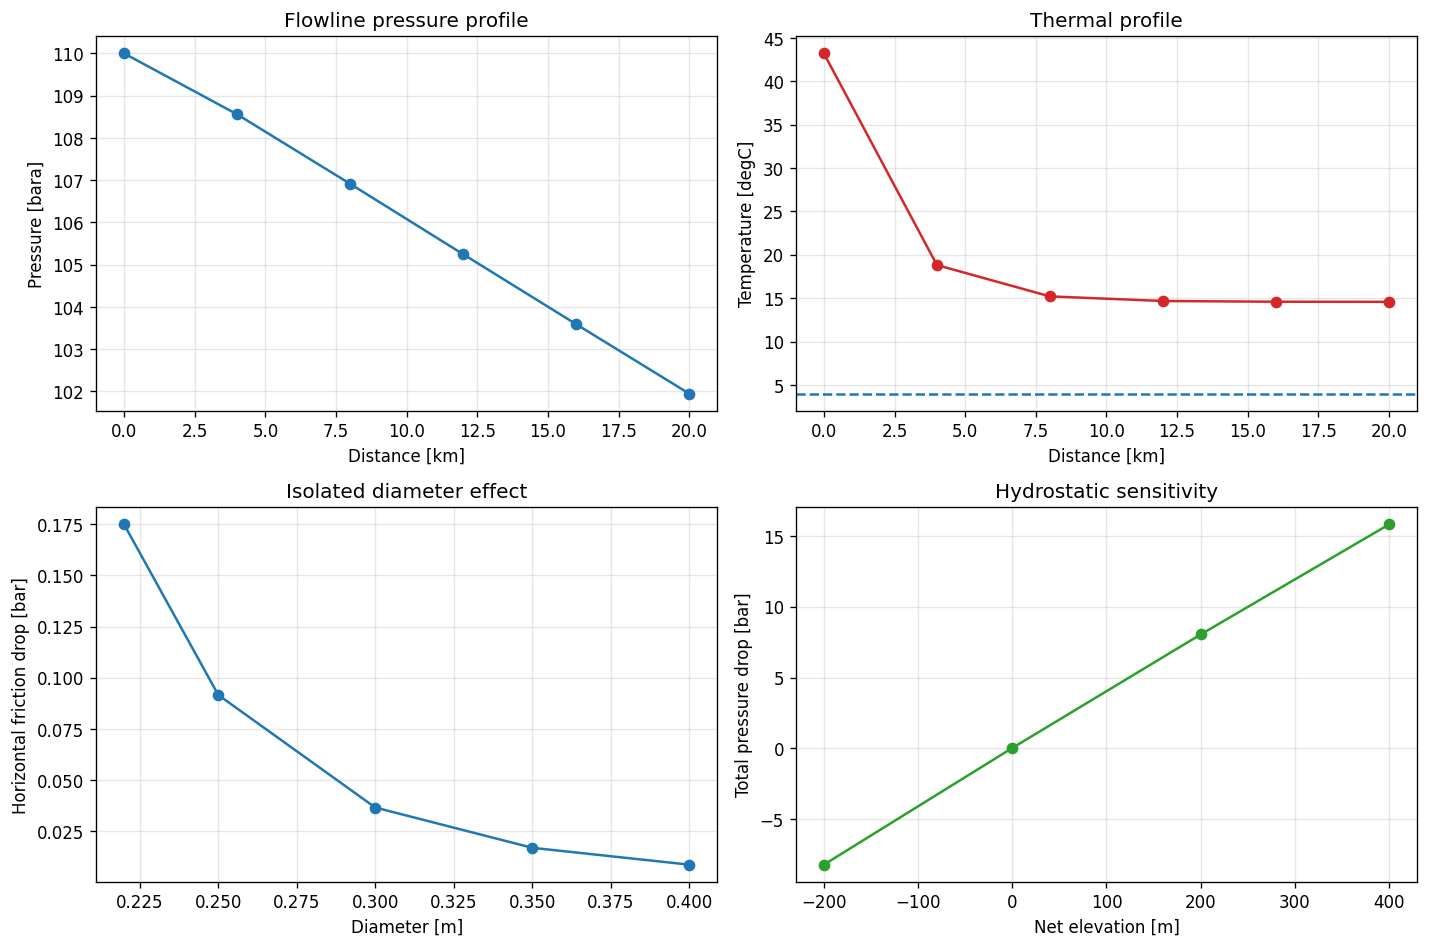

In [15]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
axes[0,0].plot(profile_table["distance [km]"],profile_table["pressure [bara]"],"o-");axes[0,0].set(xlabel="Distance [km]",ylabel="Pressure [bara]",title="Flowline pressure profile")
axes[0,1].plot(profile_table["distance [km]"],profile_table["temperature [degC]"],"o-",color="tab:red");axes[0,1].axhline(case["seawater_temperature_C"],color="tab:blue",linestyle="--");axes[0,1].set(xlabel="Distance [km]",ylabel="Temperature [degC]",title="Thermal profile")
axes[1,0].plot(diameter_table["diameter [m]"],diameter_table["pressure drop [bar]"],"o-");axes[1,0].set(xlabel="Diameter [m]",ylabel="Horizontal friction drop [bar]",title="Isolated diameter effect")
axes[1,1].plot(elevation_table["net elevation [m]"],elevation_table["pressure drop [bar]"],"o-",color="tab:green");axes[1,1].set(xlabel="Net elevation [m]",ylabel="Total pressure drop [bar]",title="Hydrostatic sensitivity")
for ax in axes.flat:ax.grid(True,alpha=0.3)
fig.tight_layout();plt.show()

## Verification and troubleshooting

Assertions check composition, phases, mass and enthalpy closure, profile consistency, thermal bounds, physical holdup, isolated friction trends, elevation behavior, component routing, compressor agreement, and velocity screening. If a run fails, check component names, units, multiphase checking, pressure ordering, positive diameter, and that the pipeline outlet remains above the host separator pressure. Near phase boundaries, small input changes can legitimately change holdup and regime.

In [16]:
checks={
    "composition closes":abs(sum(composition_mol_percent.values())-100.0)<1e-12,
    "wellstream is multiphase":well_fluid.getNumberOfPhases()==2,
    "host separation mass closes":abs(mass_residual)<1e-9,
    "subsea choke is isenthalpic":abs(subsea_h_residual)<1e-6,
    "host choke is isenthalpic":abs(host_h_residual)<1e-6,
    "profile and reported pressure drop agree":abs(profile_drop-flowline.getPressureDrop())<1e-8,
    "flowline pressure decreases":np.all(np.diff(pressure_profile)<0.0),
    "temperature remains between seawater and inlet":profile_table["temperature [degC]"].min()>case["seawater_temperature_C"] and profile_table["temperature [degC]"].max()<=case["wellhead_temperature_C"],
    "holdup is physical":np.all((holdup_profile>=0.0)&(holdup_profile<=1.0)),
    "larger horizontal diameter lowers friction drop":diameter_table["pressure drop [bar]"].is_monotonic_decreasing,
    "horizontal friction rises with throughput":rate_table["pressure drop [bar]"].is_monotonic_increasing,
    "uphill elevation raises total drop":elevation_table["pressure drop [bar]"].is_monotonic_increasing,
    "methane enriches in gas":composition_table.loc["methane","separator gas mole fraction [-]"]>composition_table.loc["methane","separator liquid mole fraction [-]"],
    "n-octane enriches in liquid":composition_table.loc["n-octane","separator liquid mole fraction [-]"]>composition_table.loc["n-octane","separator gas mole fraction [-]"],
    "compressor power is positive":neqsim_power_W>0.0,
    "simple compressor screen agrees within 35 percent":abs(simple_power_W-neqsim_power_W)/neqsim_power_W<0.35,
    "mixture velocity is below erosional screen":0.0<mixture_velocity<erosional_velocity,
}
for name,passed in checks.items():print(f"{'PASS' if passed else 'FAIL'}  {name}")
assert all(checks.values()),[name for name,passed in checks.items() if not passed]
print(f"All {len(checks)} engineering checks passed.")

PASS  composition closes
PASS  wellstream is multiphase
PASS  host separation mass closes
PASS  subsea choke is isenthalpic
PASS  host choke is isenthalpic
PASS  profile and reported pressure drop agree
PASS  flowline pressure decreases
PASS  temperature remains between seawater and inlet
PASS  holdup is physical
PASS  larger horizontal diameter lowers friction drop
PASS  horizontal friction rises with throughput
PASS  uphill elevation raises total drop
PASS  methane enriches in gas
PASS  n-octane enriches in liquid
PASS  compressor power is positive
PASS  simple compressor screen agrees within 35 percent
PASS  mixture velocity is below erosional screen
All 17 engineering checks passed.


## Summary, exercises, and references

You built and validated an integrated subsea-to-host model, inspected multiphase profiles, and separated friction, thermal, throughput, and elevation effects. Exercises: replace the synthetic fluid with characterized PVT data; add water and a dedicated three-phase inlet model; import bathymetry; test insulation and cold restart; add hydrate/wax margins; couple wells through a manifold; constrain the host separator and compressor; and compare against a qualified transient simulator.

References: [NeqSim documentation](https://equinor.github.io/neqsimhome/); Beggs and Brill, *A Study of Two-Phase Flow in Inclined Pipes*, JPT 25(5), 1973, [DOI 10.2118/4007-PA](https://doi.org/10.2118/4007-PA); ISO 13628-1, subsea production systems; and API RP 14E for offshore production-platform piping guidance. Apply the governing project standards and validate correlations against relevant data.

In [17]:
result_record={
    "neqsim_version":NEQSIM_VERSION,
    "flowline_arrival_pressure_bara":round(base["flowline"].getOutletStream().getPressure("bara"),3),
    "flowline_arrival_temperature_C":round(base["flowline"].getOutletStream().getTemperature("C"),3),
    "flowline_pressure_drop_bar":round(base["flowline"].getPressureDrop(),4),
    "separator_gas_kg_per_h":round(base["separator"].getGasOutStream().getFlowRate("kg/hr"),3),
    "separator_liquid_kg_per_h":round(base["separator"].getLiquidOutStream().getFlowRate("kg/hr"),3),
    "compressor_power_MW":round(base["compressor"].getPower()/1e6,5),
    "validated_checks":len(checks),
}
print(json.dumps(result_record,indent=2))

{
  "neqsim_version": "3.16.0",
  "flowline_arrival_pressure_bara": 101.948,
  "flowline_arrival_temperature_C": 14.582,
  "flowline_pressure_drop_bar": 8.0519,
  "separator_gas_kg_per_h": 3610.279,
  "separator_liquid_kg_per_h": 4389.721,
  "compressor_power_MW": 0.09459,
  "validated_checks": 17
}
